In [1]:
pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.9 MB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.8 MB/s eta 0:00:00

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
  Attempting uninstall: cffi
   ------------- -------------------------- 2/6 [websockets]
    Found existing installation: cffi 1.17.1
   ------------- -------------------------- 2/6 [websockets]
   -------------------

  You can safely remove it manually.


In [7]:
import pandas as pd

data = pd.read_csv("stock_data.csv")

# Rename first column
data.rename(columns={"Unnamed: 0": "Date"}, inplace=True)

# Convert to datetime
data["Date"] = pd.to_datetime(data["Date"])

# Set index
data.set_index("Date", inplace=True)

data.head()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
Date,,,,,
2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


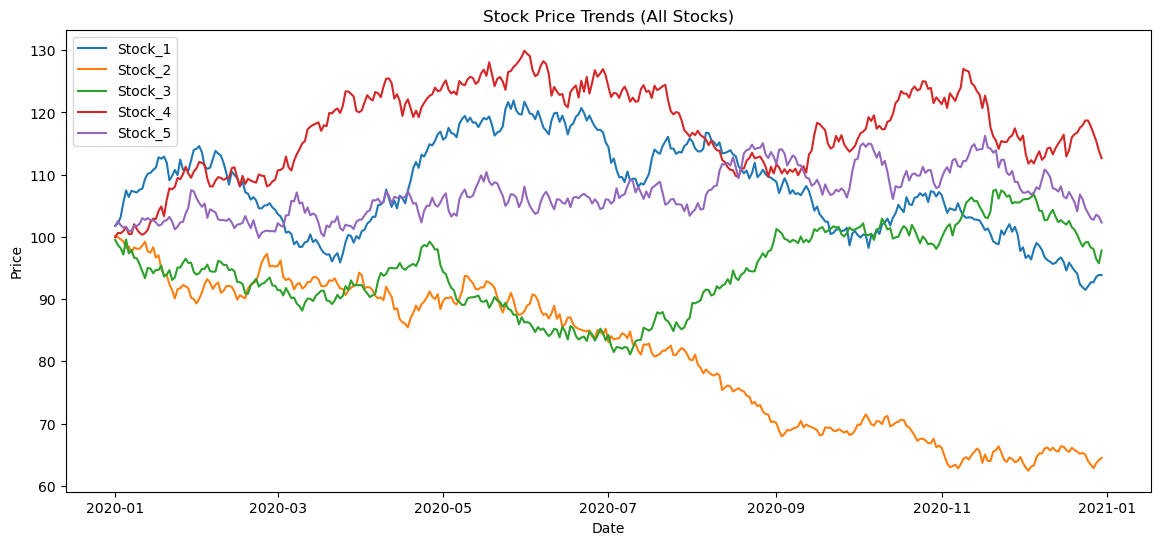

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for col in data.columns:
    plt.plot(data[col], label=col)

plt.title("Stock Price Trends (All Stocks)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [9]:
df = data[["Stock_1"]].copy()

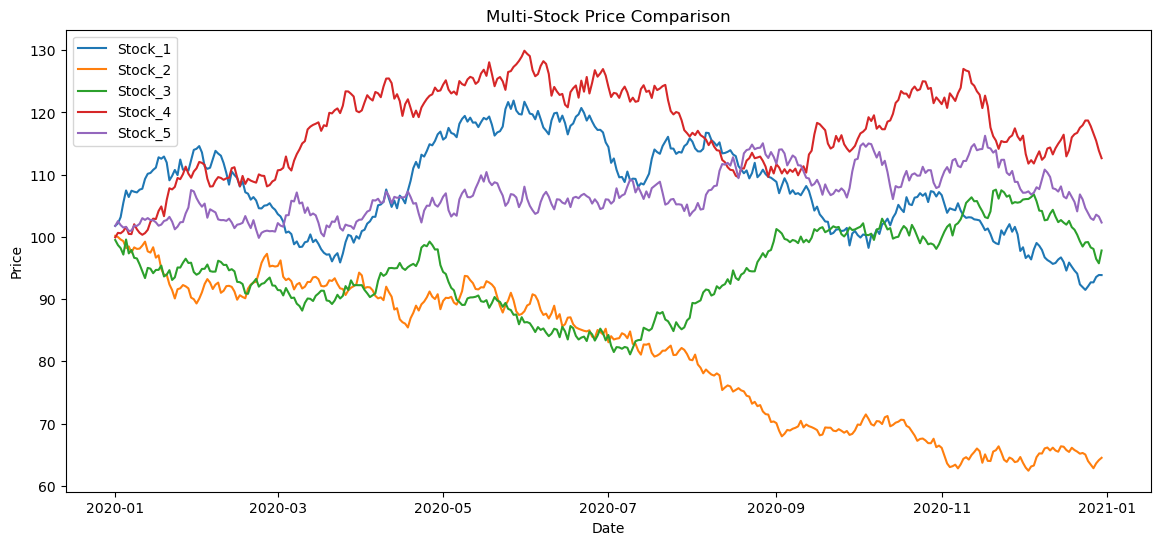

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for col in data.columns:
    plt.plot(data[col], label=col)

plt.title("Multi-Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [11]:
import numpy as np

def create_features(df, stock):
    df_new = pd.DataFrame()
    df_new["price"] = df[stock]

    # lag features
    df_new["lag1"] = df_new["price"].shift(1)
    df_new["lag2"] = df_new["price"].shift(2)
    df_new["lag3"] = df_new["price"].shift(3)

    # moving average
    df_new["ma5"] = df_new["price"].rolling(window=5).mean()

    df_new.dropna(inplace=True)
    return df_new

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

def train_model(df_feat):
    X = df_feat.drop("price", axis=1)
    y = df_feat["price"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = RandomForestRegressor(n_estimators=100)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

In [13]:
results = {}

for stock in data.columns:
    df_feat = create_features(data, stock)
    rmse = train_model(df_feat)
    results[stock] = rmse

results

{'Stock_1': np.float64(2.0623065687838738),
 'Stock_2': np.float64(4.014796592779149),
 'Stock_3': np.float64(3.4624326684212217),
 'Stock_4': np.float64(1.397704723838943),
 'Stock_5': np.float64(1.2630394290740998)}

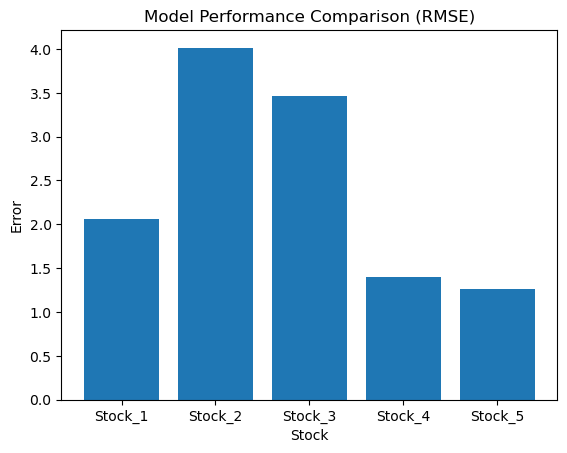

In [14]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Model Performance Comparison (RMSE)")
plt.xlabel("Stock")
plt.ylabel("Error")
plt.show()

In [15]:
def create_features(df, stock):
    df_feat = pd.DataFrame()
    df_feat["price"] = df[stock]

    # Lag features
    for i in range(1, 6):
        df_feat[f"lag_{i}"] = df_feat["price"].shift(i)

    # Moving averages (traders actually use these)
    df_feat["ma_5"] = df_feat["price"].rolling(5).mean()
    df_feat["ma_10"] = df_feat["price"].rolling(10).mean()

    # Volatility (important improvement)
    df_feat["returns"] = df_feat["price"].pct_change()
    df_feat["volatility_5"] = df_feat["returns"].rolling(5).std()

    df_feat.dropna(inplace=True)
    return df_feat

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

def train_models(df_feat):
    X = df_feat.drop("price", axis=1)
    y = df_feat["price"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    models = {
        "Linear": LinearRegression(),
        "RandomForest": RandomForestRegressor(n_estimators=100),
        "GradientBoost": GradientBoostingRegressor()
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        results[name] = (rmse, y_test, preds)

    return results

In [21]:
stock = "Stock_1"

df_feat = create_features(data, stock)
results = train_models(df_feat)

results.keys()

dict_keys(['Linear', 'RandomForest', 'GradientBoost'])